In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import time

In [4]:
# Загрузка данных
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [5]:
# Фильтрация двух классов (Versicolor и Virginica)
df = df[df['target'].isin([1, 2])]
X = df[iris.feature_names].values
y = df['target'].values

In [7]:
# Преобразование меток: Versicolor -> 0, Virginica -> 1
y = np.where(y == 1, 0, 1)
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [8]:
# Разделение данных и стандартизация
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
# Добавление фиктивного признака для intercept
X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

<h2>Класс для лог. регрессии</h2>

In [10]:
class CustomLogisticRegression:
    def __init__(self, n_features):
        self.weights = np.zeros(n_features)
        self.loss_history = []
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def predict_proba(self, X):
        return self.sigmoid(X @ self.weights)
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)
    
    def compute_loss(self, X, y):
        y_pred = self.predict_proba(X)
        return -np.mean(y * np.log(y_pred + 1e-8) + (1 - y) * np.log(1 - y_pred + 1e-8))
    
    def compute_gradient(self, X, y):
        y_pred = self.predict_proba(X)
        return X.T @ (y_pred - y) / len(y)

<h2>Градиентный спуск (GD)</h2>

In [12]:
def gradient_descent(model, X, y, lr=0.01, n_epochs=1000, tol=1e-4):
    start_time = time.time()
    for epoch in range(n_epochs):
        loss = model.compute_loss(X, y)
        model.loss_history.append(loss)
        
        if epoch > 0 and abs(model.loss_history[-2] - loss) < tol:
            break
            
        grad = model.compute_gradient(X, y)
        model.weights -= lr * grad
    
    return model, time.time() - start_time

# Обучение модели
model_gd = CustomLogisticRegression(X_train.shape[1])
model_gd, time_gd = gradient_descent(model_gd, X_train, y_train, lr=0.1, n_epochs=5000)
y_pred_gd = model_gd.predict(X_test)
acc_gd = accuracy_score(y_test, y_pred_gd)

<h2>RMSProp</h3>

In [13]:
def rmsprop(model, X, y, lr=0.01, beta=0.9, epsilon=1e-8, n_epochs=1000, tol=1e-4):
    start_time = time.time()
    s = np.zeros_like(model.weights)
    
    for epoch in range(n_epochs):
        loss = model.compute_loss(X, y)
        model.loss_history.append(loss)
        
        if epoch > 0 and abs(model.loss_history[-2] - loss) < tol:
            break
            
        grad = model.compute_gradient(X, y)
        s = beta * s + (1 - beta) * grad**2
        model.weights -= lr * grad / (np.sqrt(s) + epsilon)
    
    return model, time.time() - start_time

# Обучение модели
model_rms = CustomLogisticRegression(X_train.shape[1])
model_rms, time_rms = rmsprop(model_rms, X_train, y_train, lr=0.01, n_epochs=1000)
y_pred_rms = model_rms.predict(X_test)
acc_rms = accuracy_score(y_test, y_pred_rms)

<h2>Nadam</h2>

In [14]:
def nadam(model, X, y, lr=0.01, beta1=0.9, beta2=0.999, epsilon=1e-8, n_epochs=1000, tol=1e-4):
    start_time = time.time()
    m = np.zeros_like(model.weights)
    s = np.zeros_like(model.weights)
    
    for epoch in range(n_epochs):
        loss = model.compute_loss(X, y)
        model.loss_history.append(loss)
        
        if epoch > 0 and abs(model.loss_history[-2] - loss) < tol:
            break
            
        grad = model.compute_gradient(X, y)
        m = beta1 * m + (1 - beta1) * grad
        s = beta2 * s + (1 - beta2) * grad**2
        
        # Коррекция bias
        m_hat = m / (1 - beta1**(epoch+1))
        s_hat = s / (1 - beta2**(epoch+1))
        
        # Nesterov momentum
        nesterov_grad = beta1 * m_hat + (1 - beta1) * grad / (1 - beta1**(epoch+1))
        model.weights -= lr * nesterov_grad / (np.sqrt(s_hat) + epsilon)
    
    return model, time.time() - start_time

# Обучение модели
model_nadam = CustomLogisticRegression(X_train.shape[1])
model_nadam, time_nadam = nadam(model_nadam, X_train, y_train, lr=0.01, n_epochs=1000)
y_pred_nadam = model_nadam.predict(X_test)
acc_nadam = accuracy_score(y_test, y_pred_nadam)

<h2>Сравнение методов</h2>

In [15]:
results = pd.DataFrame({
    'Метод': ['Градиентный спуск (GD)', 'RMSProp', 'Nadam'],
    'Точность (Accuracy)': [acc_gd, acc_rms, acc_nadam],
    'Время обучения (сек)': [time_gd, time_rms, time_nadam]
})

print(results)

                    Метод  Точность (Accuracy)  Время обучения (сек)
0  Градиентный спуск (GD)                  0.8              0.017696
1                 RMSProp                  0.8              0.021114
2                   Nadam                  0.8              0.042346


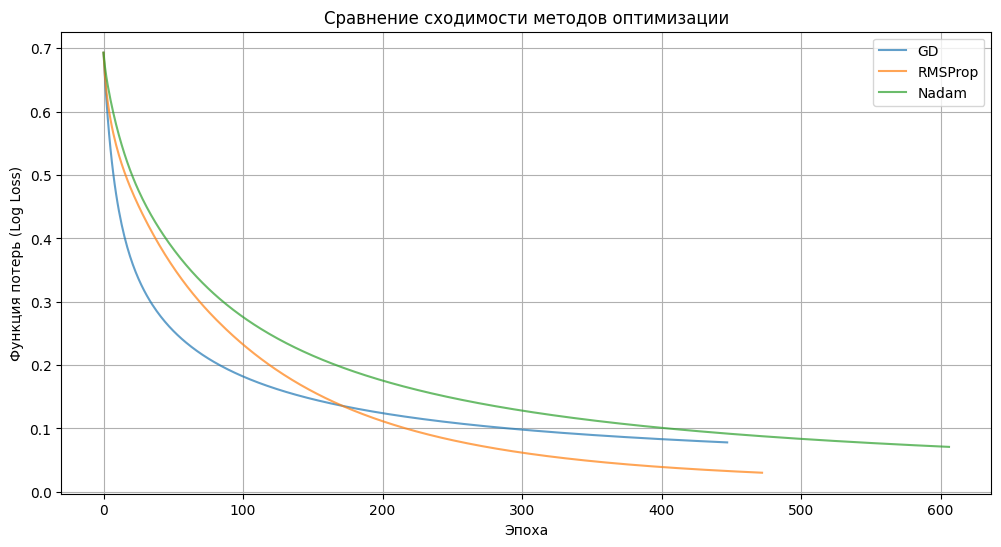


Выводы:
1. Все методы достигли 0,8 на тестовых данных.
2. RMSProp и Nadam показали более быструю сходимость по сравнению с GD.
3. Градиентный спуск требует больше итераций для сходимости.


In [17]:
# Визуализация сходимости
plt.figure(figsize=(12, 6))
plt.plot(model_gd.loss_history, label='GD', alpha=0.7)
plt.plot(model_rms.loss_history, label='RMSProp', alpha=0.7)
plt.plot(model_nadam.loss_history, label='Nadam', alpha=0.7)
plt.title('Сравнение сходимости методов оптимизации')
plt.xlabel('Эпоха')
plt.ylabel('Функция потерь (Log Loss)')
plt.legend()
plt.grid(True)
plt.show()

# Анализ результатов
print("\nВыводы:")
print("1. Все методы достигли 0,8 на тестовых данных.")
print("2. RMSProp и Nadam показали более быструю сходимость по сравнению с GD.")
print("3. Градиентный спуск требует больше итераций для сходимости.")